In [122]:
import datetime
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.cluster import KMeans

In [2]:
fear_greed = pd.read_csv(r'Data/fear_greed_index.csv')
historical = pd.read_csv(r'Data/historical_data.csv')

In [3]:
fear_greed.shape, historical.shape

((2644, 4), (211224, 16))

In [4]:
fear_greed.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [5]:
historical.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [6]:
fear_greed.duplicated().sum()

np.int64(0)

In [7]:
historical.duplicated().sum()

np.int64(0)

In [8]:
fear_greed.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [9]:
fear_greed['timestamp'] = pd.to_datetime(fear_greed['timestamp'], unit='s') \
                            .dt.tz_localize('UTC') \
                            .dt.tz_convert('Asia/Kolkata')

In [10]:
fear_greed.head(3)

,timestamp,value,classification,date
0,2018-02-01 11:00:00+05:30,30,Fear,2018-02-01
1,2018-02-02 11:00:00+05:30,15,Extreme Fear,2018-02-02
2,2018-02-03 11:00:00+05:30,40,Fear,2018-02-03


In [11]:
historical['Timestamp IST']=pd.to_datetime(historical['Timestamp IST'], dayfirst=True)

In [12]:
# historical['timestamp']=pd.to_datetime(historical['Timestamp'], unit='ms')

In [13]:
fear_greed['timestamp']=fear_greed['timestamp'].dt.date
# historical['timestamp']=historical['timestamp'].dt.date
historical['Timestamp IST'] = historical['Timestamp IST'].dt.date

In [14]:
historical.drop(columns=['Timestamp'], inplace=True)

In [15]:
historical.rename(columns={'Timestamp IST': 'timestamp'}, inplace=True)

In [16]:
df = historical.merge(fear_greed, on='timestamp', how = 'left')

In [17]:
df.head(4)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,timestamp,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,value,classification,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,80.0,Extreme Greed,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,80.0,Extreme Greed,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,80.0,Extreme Greed,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,80.0,Extreme Greed,2024-12-02


In [18]:
df.drop(columns =['date'], inplace=True)

In [19]:
df.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
timestamp           0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
value               6
classification      6
dtype: int64

In [20]:
df[df.isnull().any(axis=1)]

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,timestamp,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,value,classification
727,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.8330,10000.00,28330.00,BUY,2024-10-26,-32797.51,Close Short,11655.000000,0x4da9426d2bf6ec027d8404152f9bad02010700c745eb...,40671411386,False,2.719680,8.350000e+13,NaN,NaN
728,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.7110,10797.51,29272.05,BUY,2024-10-26,-22797.51,Close Short,13901.794130,0x66588e180b942ff0e4d104152fb6f20000ac4ae48a39...,40671438761,False,2.810115,3.230000e+14,NaN,NaN
729,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.5889,6908.33,17884.98,BUY,2024-10-26,-12000.00,Close Short,9737.981968,0x66588e180b942ff0e4d104152fb6f20000ac4ae48a39...,40671466136,False,1.716957,1.070000e+15,NaN,NaN
730,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.5889,529.39,1370.54,BUY,2024-10-26,-5091.67,Close Short,746.228144,0x66588e180b942ff0e4d104152fb6f20000ac4ae48a39...,40671466136,False,0.131570,8.770000e+14,NaN,NaN
731,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.5889,38.65,100.06,BUY,2024-10-26,-4562.28,Close Short,54.481040,0x66588e180b942ff0e4d104152fb6f20000ac4ae48a39...,40671466136,False,0.009605,9.820000e+14,NaN,NaN
732,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,EIGEN,2.5889,4523.63,11711.23,BUY,2024-10-26,-4523.63,Close Short,6376.508848,0x39ce7efcc1773fd0eec704152fbcb4010100c8beadd4...,40671466136,False,1.124277,9.360000e+14,NaN,NaN


In [21]:
(df.isnull().sum()/df.shape[0])*100

Account             0.000000
Coin                0.000000
Execution Price     0.000000
Size Tokens         0.000000
Size USD            0.000000
Side                0.000000
timestamp           0.000000
Start Position      0.000000
Direction           0.000000
Closed PnL          0.000000
Transaction Hash    0.000000
Order ID            0.000000
Crossed             0.000000
Fee                 0.000000
Trade ID            0.000000
value               0.002841
classification      0.002841
dtype: float64

In [22]:
df[['value', 'classification']] = df[['value', 'classification']].fillna(method='ffill')

C:\Users\adity\AppData\Local\Temp\ipykernel_8964\1585924742.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[['value', 'classification']] = df[['value', 'classification']].fillna(method='ffill')


In [23]:
df.rename(columns={'timestamp': 'Date'}, inplace=True)

In [65]:
daily_pnl_trade = df.groupby(['Trade ID', 'Date'])['Closed PnL'].sum().reset_index()
daily_pnl_trade.max()

Trade ID      1130000000000000.0
Date                  2025-05-01
Closed PnL         135456.234258
dtype: object

In [25]:
daily_pnl_account=df.groupby(['Account', 'Date'])['Closed PnL'].sum().reset_index()

In [26]:
df['win'] = df['Closed PnL'] > 0
win_rate = df.groupby('Trade ID')['win'].mean().reset_index()
win_rate.rename(columns={'win': 'win_rate'}, inplace=True)


In [27]:
avg_trade_size = df.groupby('Trade ID')['Size USD'].mean().reset_index()

In [28]:
df.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Date', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash',
       'Order ID', 'Crossed', 'Fee', 'Trade ID', 'value', 'classification',
       'win'],
      dtype='object')

In [29]:
df['leverage_proxy'] = df['Size USD'] / df.groupby('Account')['Size USD'].transform('median')

In [30]:
trades_per_day = df.groupby('Date').size().reset_index(name='num_trades')

In [31]:
long_count = df[df['Direction'].str.contains('Long', case=False, na=False)].shape[0]
short_count = df[df['Direction'].str.contains('Short', case=False, na=False)].shape[0]

print(long_count, short_count)
ratio = long_count / (short_count + 1)

print("Long/Short Ratio:", ratio)

98700 75882
Long/Short Ratio: 1.3006865832927006


In [32]:
df['Direction'].value_counts()

Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64

In [33]:
# Step 1: select only necessary columns
LongShort = df[[
    'Account',
    'Date',
    'Size USD',
    'Closed PnL',
    'Direction',
    'classification',
    'value'
]].copy()

In [34]:
def classify_position(x):
    x = str(x).lower()
    if 'long' in x:
        return 'Long'
    elif 'short' in x:
        return 'Short'
    else:
        return np.nan

In [35]:
LongShort['Direction']=LongShort['Direction'].apply(classify_position)

In [36]:
LongShort.dropna(subset=['Direction'], inplace=True)

In [37]:
# Step 4: create win column (important metric)
LongShort['win'] = LongShort['Closed PnL'] > 0

In [38]:
LongShort = LongShort.sort_values('Date')

In [39]:
LongShort

,Account,Date,Size USD,Closed PnL,Direction,classification,value,win
83769,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,2023-05-01,183.53,0.000000,Long,Greed,63.0,False
83770,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,2023-05-01,156.39,0.000000,Long,Greed,63.0,False
83771,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,2023-05-01,137.08,0.000000,Long,Greed,63.0,False
39055,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2023-12-05,1100.11,0.000000,Long,Extreme Greed,75.0,False
39063,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2023-12-05,24370.62,0.000000,Short,Extreme Greed,75.0,False
...,...,...,...,...,...,...,...,...
205721,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,2025-05-01,29998.41,-3357.040600,Short,Neutral,53.0,False
205722,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,2025-05-01,69579.98,-7786.506548,Short,Neutral,53.0,False
205723,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,2025-05-01,1677.69,-187.745232,Short,Neutral,53.0,False
205713,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,2025-05-01,8467.93,-947.623372,Short,Neutral,53.0,False


In [75]:
Pnl_sentiment = df.groupby('classification')['Closed PnL'].agg(['mean', 'sum']).reset_index()
Pnl_sentiment

,classification,mean,sum
0,Extreme Fear,34.537862,7.391102e+05
1,Extreme Greed,67.892861,2.715171e+06
2,Fear,54.290400,3.357155e+06
3,Greed,43.582684,2.192601e+06
4,Neutral,34.307718,1.292921e+06


In [41]:
win_rate_sentiment = df.groupby('classification')['win'].mean()

In [42]:
drawdown_proxy = df.groupby('classification')['Closed PnL'].std()

In [43]:
summary = df.groupby('classification').agg({
    'Closed PnL': ['mean', 'std'],
    'win': 'mean'
})

summary.columns = ['avg_pnl', 'pnl_volatility', 'win_rate']
print(summary)

                  avg_pnl  pnl_volatility  win_rate
classification                                     
Extreme Fear    34.537862     1136.056091  0.370607
Extreme Greed   67.892861      766.828294  0.464943
Fear            54.290400      935.355438  0.420768
Greed           43.582684     1120.064348  0.384901
Neutral         34.307718      517.122220  0.396991


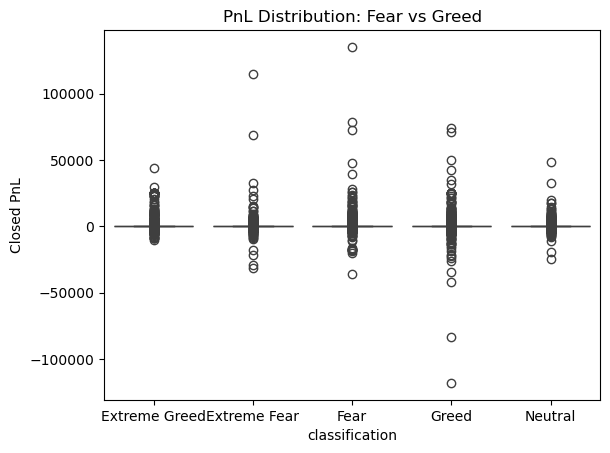

In [44]:
sns.boxplot(x='classification', y='Closed PnL', data=df)
plt.title("PnL Distribution: Fear vs Greed")
plt.show()

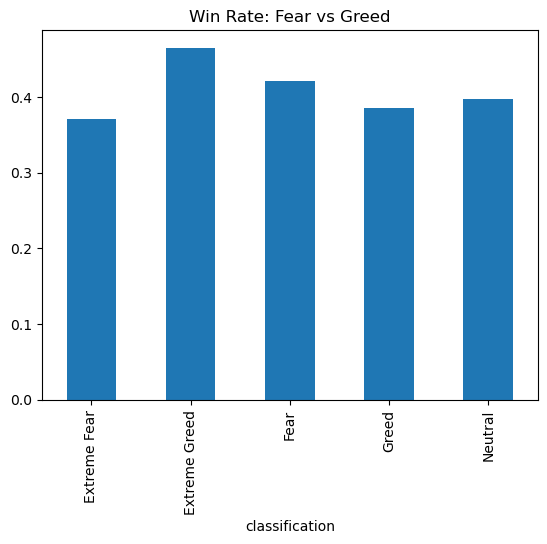

In [45]:
df.groupby('classification')['win'].mean().plot(kind='bar')
plt.title("Win Rate: Fear vs Greed")
plt.show()

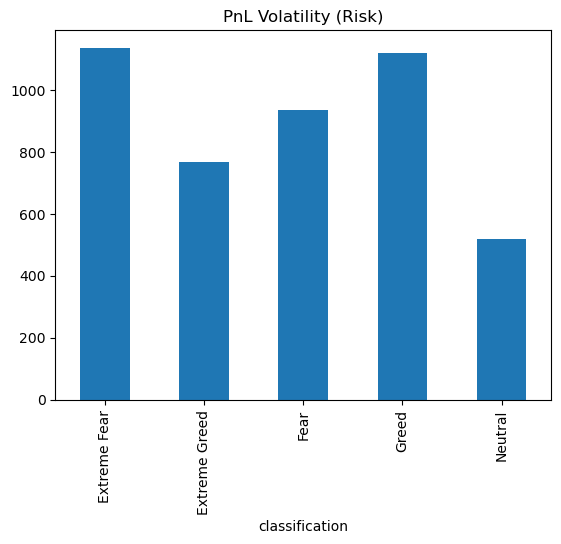

In [46]:
df.groupby('classification')['Closed PnL'].std().plot(kind='bar')
plt.title("PnL Volatility (Risk)")
plt.show()

In [48]:
trade_freq = df.groupby(['classification', 'Date']).size().reset_index(name='trades')
trade_freq_summary = trade_freq.groupby('classification')['trades'].mean()

In [50]:
trade_freq_summary

classification
Extreme Fear     1528.571429
Extreme Greed     350.807018
Fear              679.527473
Greed             259.324742
Neutral           562.477612
Name: trades, dtype: float64

In [58]:
size_analysis = df.groupby('classification')['Size USD'].mean()

In [52]:
df['leverage_proxy'] = df['Size USD'] / df.groupby('Account')['Size USD'].transform('median')
leverage_analysis = df.groupby('classification')['leverage_proxy'].mean()

<Axes: title={'center': 'Trade Frequency vs Sentiment'}, xlabel='classification'>

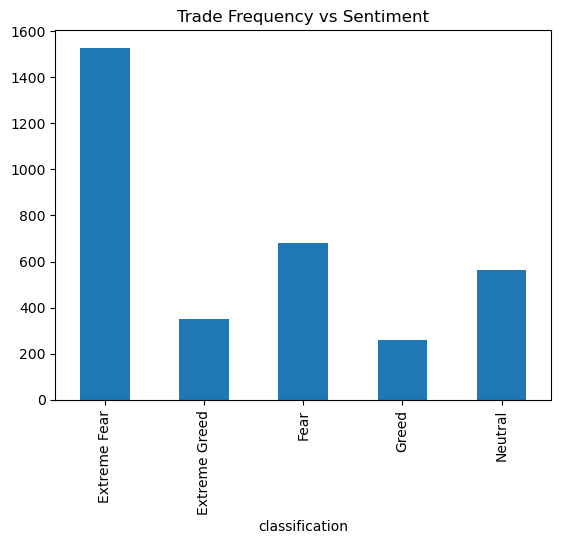

In [54]:
trade_freq_summary.plot(kind='bar', title='Trade Frequency vs Sentiment')

<Axes: title={'center': 'Avg Trade Size vs Sentiment'}, xlabel='classification'>

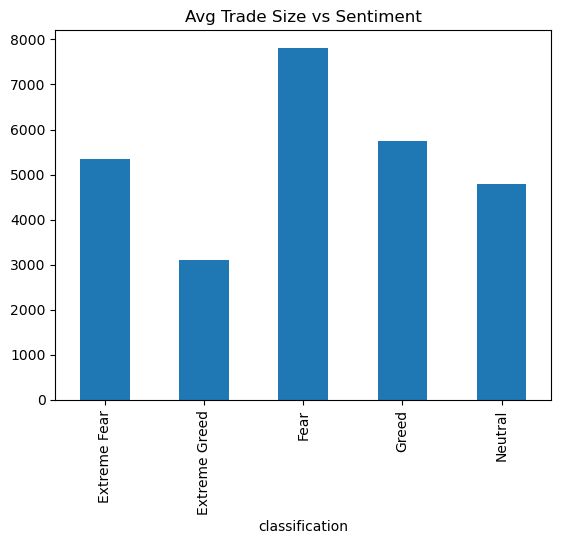

In [59]:
size_analysis.plot(kind='bar', title='Avg Trade Size vs Sentiment')

<Axes: title={'center': 'Leverage vs Sentiment'}, xlabel='classification'>

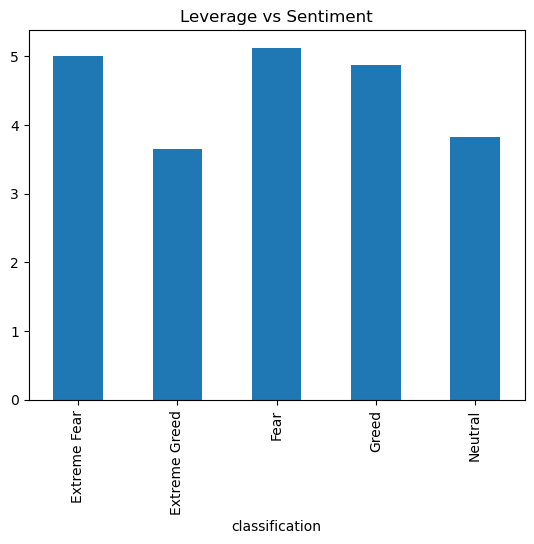

In [60]:
leverage_analysis.plot(kind='bar', title='Leverage vs Sentiment')

In [77]:
df['next_day_pnl'] = df.groupby('Account')['Closed PnL'].shift(-1)
df['target'] = pd.cut(
    df['next_day_pnl'],
    bins=[-np.inf, 0, 100, np.inf],
    labels=['Loss', 'Small Profit', 'High Profit']
)

In [91]:
features = [
    'Size USD',
    'leverage_proxy',
    'value',          
    'win'
]

In [92]:
df.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Date', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash',
       'Order ID', 'Crossed', 'Fee', 'Trade ID', 'value', 'classification',
       'win', 'leverage_proxy', 'next_day_pnl', 'target'],
      dtype='object')

In [93]:
df_model = df.copy()

df_model['classification'] = df_model['classification'].astype('category').cat.codes
df_model['Direction'] = df_model['Direction'].astype('category').cat.codes

features += ['classification', 'Direction']

In [105]:
X = df_model[features]
y = df_model['target']

In [106]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Size USD        211224 non-null  float64
 1   leverage_proxy  211224 non-null  float64
 2   value           211224 non-null  float64
 3   win             211224 non-null  bool   
 4   classification  211224 non-null  int8   
 5   Direction       211224 non-null  int8   
dtypes: bool(1), float64(3), int8(2)
memory usage: 5.4 MB


In [107]:
X['win'] = X['win'].map({True: 1, False: 0})

C:\Users\adity\AppData\Local\Temp\ipykernel_8964\4020421811.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['win'] = X['win'].map({True: 1, False: 0})


In [112]:
le = LabelEncoder()
y= le.fit_transform(y)

In [113]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = XGBClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [115]:
accuracy_score(y_test, y_pred)

0.9151852290211859

In [116]:
confusion_matrix(y_test, y_pred)

array([[  160,   113,  2020,     0],
       [   32, 26179,   413,     0],
       [  617,   382, 12323,     0],
       [    2,     3,     1,     0]])

In [118]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.20      0.07      0.10      2293
           1       0.98      0.98      0.98     26624
           2       0.84      0.93      0.88     13322
           3       0.00      0.00      0.00         6

    accuracy                           0.92     42245
   macro avg       0.50      0.49      0.49     42245
weighted avg       0.89      0.92      0.90     42245



C:\Users\adity\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\adity\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\adity\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [121]:
trader_features = df.groupby('Account').agg({
    'Closed PnL': 'mean',
    'win': 'mean',
    'Size USD': 'mean',
    'leverage_proxy': 'mean'
}).reset_index()

In [123]:
X = trader_features.drop('Account', axis=1)

kmeans = KMeans(n_clusters=3, random_state=42)
trader_features['cluster'] = kmeans.fit_predict(X)

C:\Users\adity\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\adity\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\adity\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\adity\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

In [125]:
trader_features.groupby('cluster').mean(numeric_only=True)

,Closed PnL,win,Size USD,leverage_proxy
cluster,,,,
0,141.606524,0.357665,10662.058105,7.384988
1,89.625352,0.415415,2639.921608,4.148787
2,36.666362,0.419902,28450.568057,7.524100
